# Image Classification Transfer Learning Comparison

This notebook implements and compares transfer learning across four classic convolutional neural network architectures:
- **AlexNet**
- **VGG16**
- **ResNet50**
- **EfficientNetB0**

### Key Features & Configurations:
- **Device-Agnostic Execution**: Configured for NVIDIA GeForce RTX 4050 GPU / CUDA 12.4.
- **Windows OpenMP Fix**: Handled `KMP_DUPLICATE_LIB_OK` environment issue.
- **Performance Optimization**: Uses `pin_memory=True` in DataLoaders.
- **Modular Workflow**: Standardized training/validation loop and performance visualization.

In [1]:
# Windows OpenMP Duplicate Library Fix
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check and set compute device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Dataset Setup & Preprocessing
We use CIFAR-10 as our image dataset. Standard ImageNet mean and standard deviation are applied for pre-trained model transfer learning compatibility.

In [2]:
# Standard ImageNet normalization constants
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Training data transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Validation/Testing transformations
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# Load CIFAR-10 Dataset
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=val_transform)

batch_size = 32
num_workers = 2

# DataLoaders with CUDA pin_memory enabled
train_loader = DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=True if torch.cuda.is_available() else False
)
val_loader = DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False,
    num_workers=num_workers, pin_memory=True if torch.cuda.is_available() else False
)

classes = train_dataset.classes
num_classes = len(classes)
print(f"Classes ({num_classes}): {classes}")

100%|██████████| 170M/170M [02:34<00:00, 1.11MB/s] 


Classes (10): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2. Generic Training & Evaluation Loop

In [3]:
def train_model(model, criterion, optimizer, num_epochs=5):
    start_time = time.time()
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print('-' * 20)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data batches
            for inputs, labels in dataloader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())

            print(f"{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    total_time = time.time() - start_time
    print(f"Training complete in {total_time // 60:.0f}m {total_time % 60:.0f}s")
    print(f"Best Val Acc: {best_acc:.4f}")
    
    model.load_state_dict(best_model_wts)
    return model, history, total_time

## 3. Model Initialization (Transfer Learning Setup)

In [4]:
def initialize_model(model_name, num_classes, feature_extract=True):
    model_ft = None

    if model_name == 'alexnet':
        model_ft = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
        if feature_extract:
            for param in model_ft.parameters():
                param.requires_grad = False
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)

    elif model_name == 'vgg16':
        model_ft = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        if feature_extract:
            for param in model_ft.parameters():
                param.requires_grad = False
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)

    elif model_name == 'resnet50':
        model_ft = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        if feature_extract:
            for param in model_ft.parameters():
                param.requires_grad = False
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)

    elif model_name == 'efficientnet_b0':
        model_ft = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        if feature_extract:
            for param in model_ft.parameters():
                param.requires_grad = False
        num_ftrs = model_ft.classifier[1].in_features
        model_ft.classifier[1] = nn.Linear(num_ftrs, num_classes)

    return model_ft

## 4. Model Training & Benchmarking

In [5]:
models_to_test = ['alexnet', 'vgg16', 'resnet50', 'efficientnet_b0']
results = {}
num_epochs = 3
criterion = nn.CrossEntropyLoss()

for m_name in models_to_test:
    print(f"\n==================== Training {m_name.upper()} ====================")
    model = initialize_model(m_name, num_classes=num_classes, feature_extract=True)
    model = model.to(device)
    
    # Train only trainable parameters
    params_to_update = [p for p in model.parameters() if p.requires_grad]
    optimizer = optim.Adam(params_to_update, lr=0.001)
    
    trained_model, history, train_time = train_model(model, criterion, optimizer, num_epochs=num_epochs)
    
    results[m_name] = {
        'history': history,
        'train_time': train_time,
        'best_acc': max(history['val_acc'])
    }


==================== Training ALEXNET ====================


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to C:\Users\Tejas/.cache\torch\hub\checkpoints\alexnet-owt-7be5be79.pth
100%|██████████| 233M/233M [00:09<00:00, 26.2MB/s] 


Epoch 1/3
--------------------
Train Loss: 0.7642 Acc: 0.7413
Val Loss: 0.6013 Acc: 0.7968
Epoch 2/3
--------------------
Train Loss: 0.6881 Acc: 0.7717
Val Loss: 0.5911 Acc: 0.8016
Epoch 3/3
--------------------
Train Loss: 0.6775 Acc: 0.7803
Val Loss: 0.6610 Acc: 0.7903
Training complete in 5m 52s
Best Val Acc: 0.8016

==================== Training VGG16 ====================


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\Tejas/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:21<00:00, 25.5MB/s] 


Epoch 1/3
--------------------
Train Loss: 0.6784 Acc: 0.7669
Val Loss: 0.5151 Acc: 0.8200
Epoch 2/3
--------------------
Train Loss: 0.6597 Acc: 0.7812
Val Loss: 0.5233 Acc: 0.8216
Epoch 3/3
--------------------
Train Loss: 0.6597 Acc: 0.7877
Val Loss: 0.4782 Acc: 0.8366
Training complete in 16m 45s
Best Val Acc: 0.8366

==================== Training RESNET50 ====================


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Tejas/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:03<00:00, 26.0MB/s]


Epoch 1/3
--------------------
Train Loss: 0.7972 Acc: 0.7425
Val Loss: 0.5835 Acc: 0.8028
Epoch 2/3
--------------------
Train Loss: 0.6052 Acc: 0.7941
Val Loss: 0.5480 Acc: 0.8131
Epoch 3/3
--------------------
Train Loss: 0.5598 Acc: 0.8086
Val Loss: 0.5332 Acc: 0.8142
Training complete in 9m 17s
Best Val Acc: 0.8142

==================== Training EFFICIENTNET_B0 ====================


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Tejas/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 26.6MB/s]


Epoch 1/3
--------------------
Train Loss: 0.8857 Acc: 0.7141
Val Loss: 0.6438 Acc: 0.7848
Epoch 2/3
--------------------
Train Loss: 0.7304 Acc: 0.7528
Val Loss: 0.5940 Acc: 0.7986
Epoch 3/3
--------------------
Train Loss: 0.7061 Acc: 0.7615
Val Loss: 0.5790 Acc: 0.8006
Training complete in 4m 50s
Best Val Acc: 0.8006


## 5. Performance Comparison & Visualization

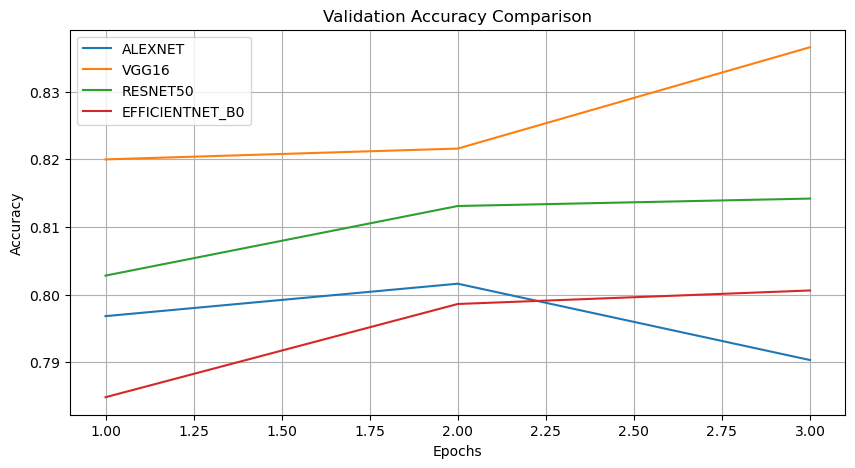


Model              | Best Val Accuracy  | Training Time (s) 
------------------------------------------------------------
ALEXNET            | 80.16            % | 352.06            
VGG16              | 83.66            % | 1005.29           
RESNET50           | 81.42            % | 556.69            
EFFICIENTNET_B0    | 80.06            % | 290.20            


In [6]:
# Plotting Validation Accuracy Comparison
plt.figure(figsize=(10, 5))
for m_name, res in results.items():
    plt.plot(range(1, num_epochs + 1), res['history']['val_acc'], label=m_name.upper())
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Summary Table
print(f"\n{'Model':<18} | {'Best Val Accuracy':<18} | {'Training Time (s)':<18}")
print("-" * 60)
for m_name, res in results.items():
    print(f"{m_name.upper():<18} | {res['best_acc']*100:<17.2f}% | {res['train_time']:<18.2f}")